# Solshade Tutorial

This notebook demonstrates how to use **Solshade** to perform terrain-aware solar illumination modeling. It reproduces the functionality of the command-line interface (CLI) tools in Python.

We will:
1. Load a DEM
2. Compute slope, aspect, normals, hillshade, and horizon
3. Compute solar flux time series
4. Generate energy metrics (daily, total, peak, day-of-peak)
5. Visualize outputs

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from pyproj import Transformer
from rasterio.transform import rowcol

from solshade.irradiance import compute_energy_metrics, compute_flux_timeseries
from solshade.solar import compute_solar_ephem, solar_envelope_by_folding
from solshade.terrain import compute_hillshade, compute_horizon_map, compute_slope_aspect_normals, load_dem
from solshade.utils import parse_iso_utc
from solshade.viz import (
    plot_aspect,
    plot_day_of_peak,
    plot_dem,
    plot_hillshade,
    plot_horizon_polar,
    plot_normals,
    plot_peak_energy,
    plot_slope,
    plot_total_energy,
)

plt.rcParams["font.family"] = "serif"
plt.style.use("dark_background")

## Download test data

In [2]:
!mkdir -p data/tifs
!wget -nc -O data/tifs/MARS.tif https://raw.githubusercontent.com/amanchokshi/solshade/main/tests/data/MARS.tif

--2026-04-10 12:12:04--  https://raw.githubusercontent.com/amanchokshi/solshade/main/tests/data/MARS.tif
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6257905 (6.0M) [image/tiff]
Saving to: ‘data/tifs/MARS.tif’

data/tifs/MARS.tif  100%[===================>]   5.97M  26.6MB/s    in 0.2s    

2026-04-10 12:12:05 (26.6 MB/s) - ‘data/tifs/MARS.tif’ saved [6257905/6257905]



## Load DEM

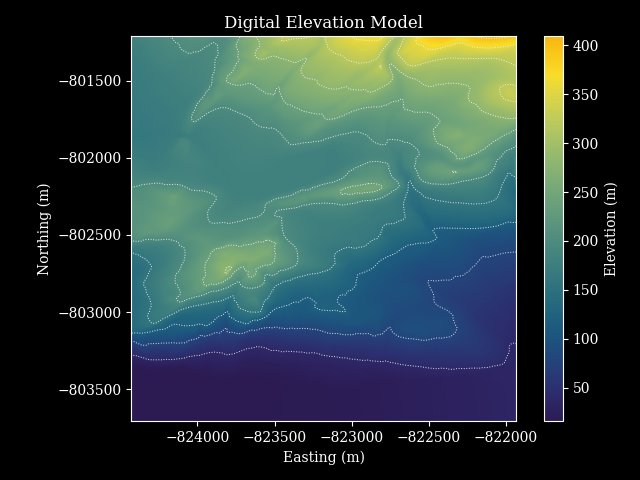

In [3]:
%matplotlib widget

DEM_PATH = Path("data/tifs/MARS.tif")
dem = load_dem(DEM_PATH)

plot_dem(dem)
plt.tight_layout()
plt.show()

## Compute Slope, Aspect, Normals, Hillshade, Horizon

In [4]:
slope, aspect, normals = compute_slope_aspect_normals(dem)
hillshade = compute_hillshade(slope, aspect, azimuth_deg=315, altitude_deg=45)
horizon = compute_horizon_map(dem, n_directions=360, max_distance=2000, step=20, chunk_size=32, n_jobs=-1)

Output()

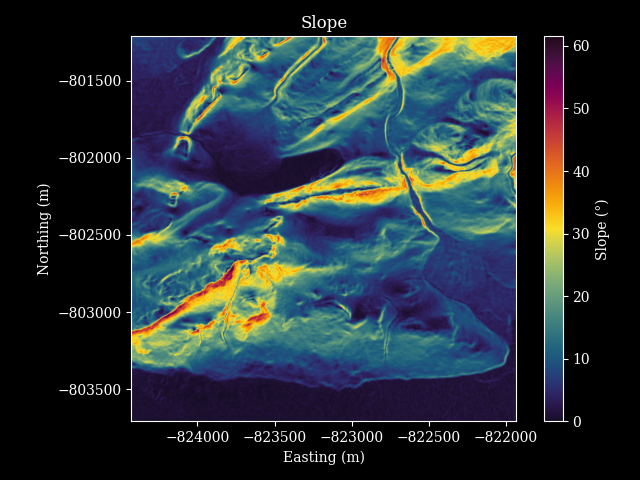

In [5]:
%matplotlib widget

plot_slope(slope)
plt.tight_layout()
plt.show()

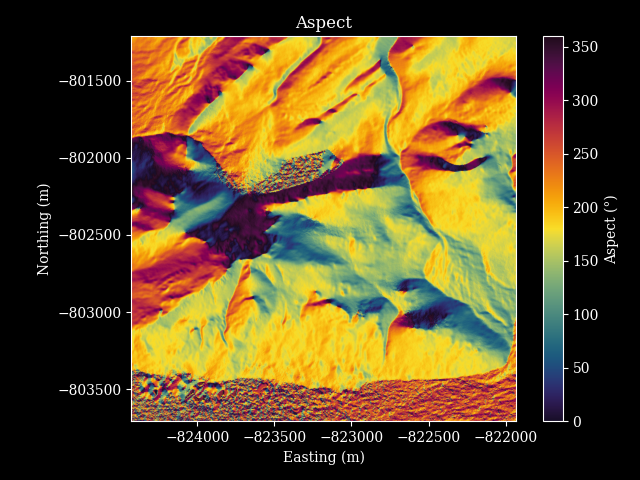

In [6]:
%matplotlib widget

plot_aspect(aspect)
plt.tight_layout()
plt.show()

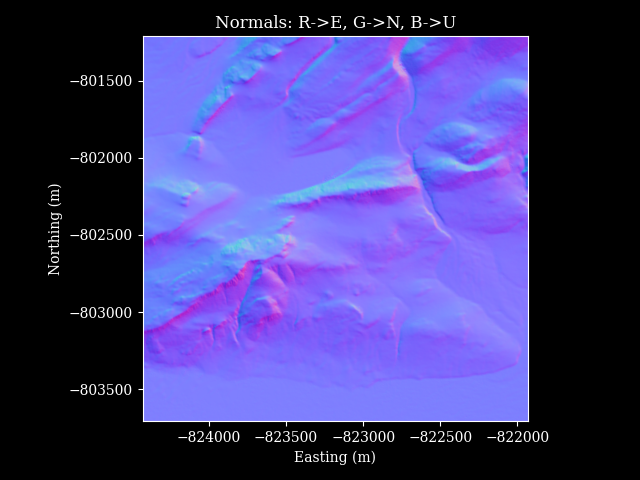

In [7]:
%matplotlib widget

plot_normals(normals)
plt.tight_layout()
plt.show()

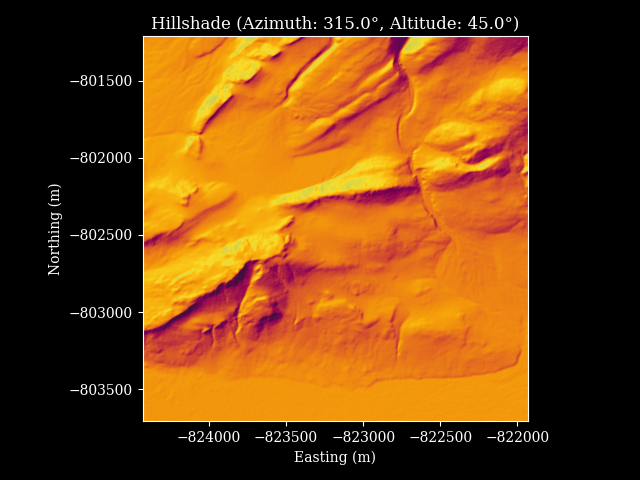

In [8]:
%matplotlib widget

plot_hillshade(slope, aspect)
plt.tight_layout()
plt.show()

[#################################] 100% de440s.bsp


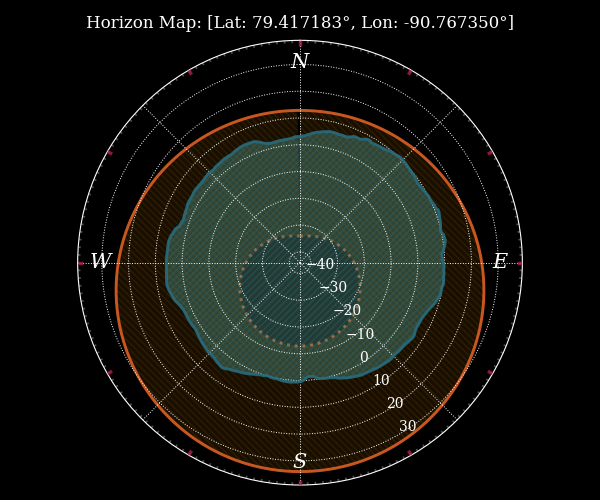

In [9]:
%matplotlib widget

lat, lon = 79.417183, -90.767350


# Reproject the query lon/lat into the raster CRS and find its pixel
transformer = Transformer.from_crs("EPSG:4326", horizon.rio.crs, always_xy=True)
x, y = transformer.transform(lon, lat)

transform = horizon.rio.transform()
row, col = rowcol(transform, x, y)

ny, nx = horizon.shape[1], horizon.shape[2]
if not (0 <= row < ny and 0 <= col < nx):
    # Build friendly bounds in geographic coords
    left, bottom, right, top = horizon.rio.bounds()
    reverse_transformer = Transformer.from_crs(horizon.rio.crs, "EPSG:4326", always_xy=True)
    lon_min, lat_min = reverse_transformer.transform(left, bottom)
    lon_max, lat_max = reverse_transformer.transform(right, top)
    raise Exception(
        f"LAT/LON ({lat:.6f}, {lon:.6f}) falls outside the raster bounds.\n"
        f"Valid LAT range: [{lat_min:.6f}, {lat_max:.6f}]\n"
        f"Valid LON range: [{lon_min:.6f}, {lon_max:.6f}]"
    )

# Read azimuth axis and the horizon profile at the target pixel
azimuths = np.asarray(json.loads(horizon.attrs["azimuths_deg"]))
profile = horizon[:, row, col].values

# Make the plot
_, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(6, 5))


times_utc, alt_deg, az_deg, _, _ = compute_solar_ephem(
    lat=lat,
    lon=lon,
    startutc=parse_iso_utc("2025-01-01T00:00:00Z"),
    stoputc=parse_iso_utc("2026-01-01T00:00:00Z"),
    timestep=3600,
    cache_dir=("data/skyfield"),
)
az_smooth, min_alt_smooth, max_alt_smooth = solar_envelope_by_folding(times_utc, alt_deg, az_deg, smooth_n=360)
sun_kwargs = {"sunaz": az_smooth, "sunaltmin": min_alt_smooth, "sunaltmax": max_alt_smooth}

plot_horizon_polar(azimuths, profile, ax, **sun_kwargs)
ax.set_title(f"Horizon Map: [Lat: {lat:.6f}°, Lon: {lon:.6f}°]", va="bottom")

plt.tight_layout()

## Compute Solar Ephemerides and Flux Time Series

In [10]:
ny, nx = dem.shape[-2:]
cy, cx = ny // 2, nx // 2
x, y = dem.rio.transform() * (cx + 0.5, cy + 0.5)
if dem.rio.crs and dem.rio.crs.to_epsg() != 4326:
    transformer = Transformer.from_crs(dem.rio.crs, "EPSG:4326", always_xy=True)
    lon_derived, lat_derived = transformer.transform(x, y)
else:
    lon_derived, lat_derived = x, y
lat_val: float = float(lat_derived)
lon_val: float = float(lon_derived)


times, alt, az, au, enu = compute_solar_ephem(
    lat=lat, lon=lon, startutc=parse_iso_utc("2025-01-01T00:00:00Z"), stoputc=parse_iso_utc("2026-01-01T00:00:00Z")
)
flux = compute_flux_timeseries(horizon, alt, az, au, enu, normals, times, batch_size=512, n_jobs=-1)

Output()

## Compute Energy Metrics

In [11]:
daily, total, peak, daypeak = compute_energy_metrics(flux)

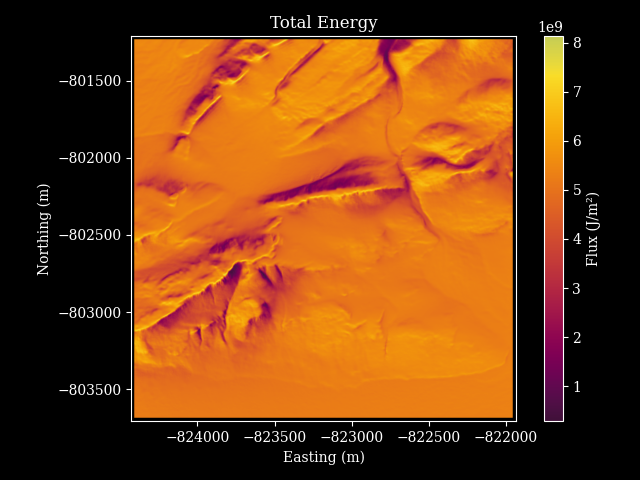

In [12]:
%matplotlib widget

plot_total_energy(total)
plt.tight_layout()
plt.show()

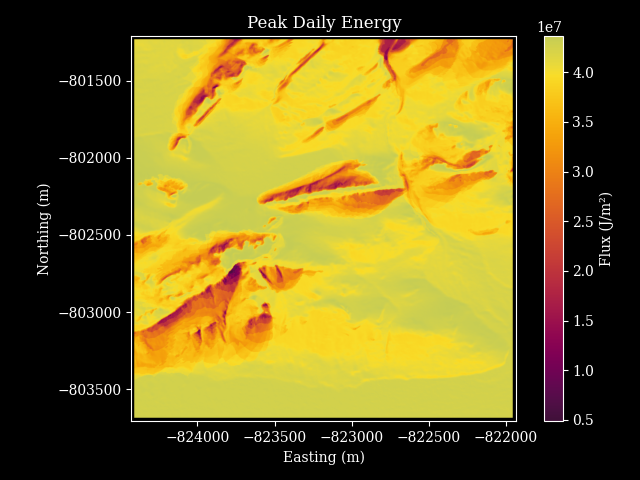

In [13]:
%matplotlib widget

plot_peak_energy(peak)
plt.tight_layout()
plt.show()

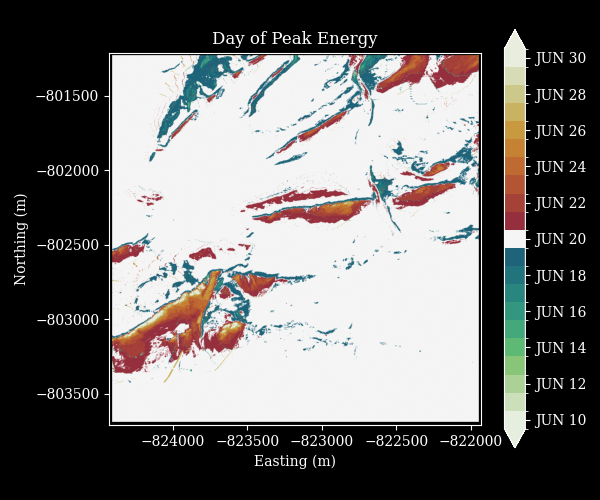

In [14]:
%matplotlib widget

daily_iso = np.datetime_as_string(daily.time.astype("datetime64[s]"), unit="s", timezone="UTC").tolist()  # type: ignore
daily_iso = np.array([s.rstrip("Z") for s in daily_iso], dtype="datetime64[s]")

plot_day_of_peak(daypeak, daily_iso, sigma=9)
plt.tight_layout()
plt.show()